# World Cup 2022 — Generic Knockout Bracket with Third-Place Match

## Overview

In this notebook, we reconstruct the knockout stage of the FIFA World Cup 2022 using a fully generic, data-driven approach. Starting from relational match-level data stored in a SQL database, we derive the tournament structure and visualize it as a complete knockout bracket, including the third-place match.

Rather than relying on predefined bracket layouts, we infer the progression of the tournament directly from the data. This allows the same workflow to be applied to any similar single-elimination competition.

---

## Workflow

> **relational data → structural representation → visual insight**

The notebook follows a typical data analysis pipeline:

### 1. Data Retrieval (SQL)
We query all knockout-stage matches for a selected tournament using SQL.  
This includes:
- team names  
- match results  
- stage information  
- penalty shootouts (if applicable)  

### 2. Data Transformation (pandas)
Using pandas, we:
- group matches by tournament stage  
- determine round order dynamically  
- assign matches to bracket positions  
- compute winners and formatted score labels  

We also separate the **third-place match**, since it does not belong to the main elimination tree.

### 3. Structure Inference
We reconstruct the bracket by:
- linking matches across rounds  
- determining parent-child relationships  
- computing spatial layout (x/y positions)  

This step is crucial:  
the bracket is **not stored**, but **derived**.

### 4. Visualization (matplotlib)
We manually draw the bracket using:
- rectangles for matches  
- lines for progression  
- annotations for teams and scores  

This demonstrates how complex, domain-specific visualizations can be built from first principles.

---

## Key Insight

Databases store *facts*, not *structure*.

The structure of a tournament — including progression, hierarchy, and flow — must be reconstructed through data transformation and domain logic.

This example highlights an important pattern in data science:
> meaningful representations are often *derived*, not directly stored.

---

## Extensions

This approach can be extended in several directions:

- Apply the same logic to other tournaments (e.g. UEFA, NBA playoffs)  
- Add interactivity using Plotly (hover for match metadata, filtering, etc.)  
- Integrate into dashboards or analytical pipelines  
- Compare tournament paths across years  

---

## TLDR:

This notebook provides a compact but powerful example of how to:
- bridge SQL and Python,
- reconstruct hidden structure from data,
- and create custom, domain-specific visualizations.

### ============================================================
### 1. SETTINGS AND HELPERS
### ============================================================

In [15]:
import math
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# Example:
from sqlalchemy import create_engine
engine = create_engine("sqlite:///worldcup.db")
# or PostgreSQL connection, etc.

# Inspect the used tables data
# tournaments table:
print("tournaments table:")
q = '''SELECT * FROM tournaments ORDER BY year DESC LIMIT 5;'''
df = pd.read_sql(q, engine)
display(df.head())

# tournament_stages table: 
print("tournament_stages table:")
q = '''SELECT * FROM tournament_stages LIMIT 5;'''
df = pd.read_sql(q, engine)
display(df.head())

# teams table:
print("teams table:")
q = '''SELECT * FROM teams LIMIT 5;'''
df = pd.read_sql(q, engine)
display(df.head())

# matches table:
print("matches table:")
q = '''SELECT * FROM matches LIMIT 5;'''
df = pd.read_sql(q, engine)
display(df.head())

tournaments table:


,tournament_id,tournament_name,year,start_date,end_date,host_country,winner,host_won,count_teams,group_stage,second_group_stage,final_round,round_of_16,quarter_finals,semi_finals,third_place_match,final
0,WC-2022,2022 FIFA Men's World Cup,2022,19316,19344,Qatar,Argentina,0,32,1,0,0,1,1,1,1,1
1,WC-2019,2019 FIFA Women's World Cup,2019,18054,18084,France,United States,0,24,1,0,0,1,1,1,1,1
2,WC-2018,2018 FIFA Men's World Cup,2018,17696,17727,Russia,France,0,32,1,0,0,1,1,1,1,1
3,WC-2015,2015 FIFA Women's World Cup,2015,16592,16621,Canada,United States,0,24,1,0,0,1,1,1,1,1
4,WC-2014,2014 FIFA Men's World Cup,2014,16233,16264,Brazil,Germany,0,32,1,0,0,1,1,1,1,1


tournament_stages table:


,tournament_id,stage_number,stage_name,group_stage,knockout_stage,unbalanced_groups,start_date,end_date,count_matches,count_teams,count_scheduled,count_replays,count_playoffs,count_walkovers
0,WC-1930,1,group stage,1,0,1,-14417,-14408,15,13,15,0,0,0
1,WC-1930,2,semi-finals,0,1,0,-14404,-14403,2,4,2,0,0,0
2,WC-1930,3,final,0,1,0,-14400,-14400,1,2,1,0,0,0
3,WC-1934,1,round of 16,0,1,0,-13003,-13003,8,16,8,0,0,0
4,WC-1934,2,quarter-finals,0,1,0,-12999,-12998,5,8,4,1,0,0


teams table:


,team_id,team_name,team_code,mens_team,womens_team,federation_name,region_name,confederation_id,mens_team_wikipedia_link,womens_team_wikipedia_link,federation_wikipedia_link
0,T-01,Algeria,DZA,1,0,Algerian Football Federation,Africa,CF-2,https://en.wikipedia.org/wiki/Algeria_national...,not applicable,https://en.wikipedia.org/wiki/Algerian_Footbal...
1,T-02,Angola,AGO,1,0,Angolan Football Federation,Africa,CF-2,https://en.wikipedia.org/wiki/Angola_national_...,not applicable,https://en.wikipedia.org/wiki/Angolan_Football...
2,T-03,Argentina,ARG,1,1,Argentine Football Association,South America,CF-4,https://en.wikipedia.org/wiki/Argentina_nation...,https://en.wikipedia.org/wiki/Argentina_women'...,https://en.wikipedia.org/wiki/Argentine_Footba...
3,T-04,Australia,AUS,1,1,Football Australia,Oceania,CF-1,https://en.wikipedia.org/wiki/Australia_men%27...,https://en.wikipedia.org/wiki/Australia_women'...,https://en.wikipedia.org/wiki/Football_Australia
4,T-05,Austria,AUT,1,0,Austrian Football Association,Europe,CF-6,https://en.wikipedia.org/wiki/Austria_national...,not applicable,https://en.wikipedia.org/wiki/Austrian_Footbal...


matches table:


,tournament_id,match_id,match_name,stage_name,group_name,group_stage,knockout_stage,replayed,replay,match_date,...,away_team_score_margin,extra_time,penalty_shootout,score_penalties,home_team_score_penalties,away_team_score_penalties,result,home_team_win,away_team_win,draw
0,WC-1930,M-1930-01,France vs Mexico,group stage,Group 1,1,0,0,0,-14417.0,...,-3,0,0,0-0,0,0,home team win,1,0,0
1,WC-1930,M-1930-02,United States vs Belgium,group stage,Group 4,1,0,0,0,-14417.0,...,-3,0,0,0-0,0,0,home team win,1,0,0
2,WC-1930,M-1930-03,Yugoslavia vs Brazil,group stage,Group 2,1,0,0,0,-14416.0,...,-1,0,0,0-0,0,0,home team win,1,0,0
3,WC-1930,M-1930-04,Romania vs Peru,group stage,Group 3,1,0,0,0,-14416.0,...,-2,0,0,0-0,0,0,home team win,1,0,0
4,WC-1930,M-1930-05,Argentina vs France,group stage,Group 1,1,0,0,0,-14415.0,...,-1,0,0,0-0,0,0,home team win,1,0,0


![](brackets_schema.png)

In [7]:
# Select the tournament ID for the 2022 World Cup
TOURNAMENT_ID = "WC-2022"

### ============================================================
### 2. SQL QUERY
### ============================================================

In [8]:
query = f"""
WITH match_base AS (
    SELECT
        m.match_id,
        m.match_name,
        m.match_date,
        m.stage_name,
        ts.stage_number AS stage_sequence,
        home.team_name AS home_team,
        away.team_name AS away_team,
        m.home_team_score AS home_score,
        m.away_team_score AS away_score,
        m.home_team_score_penalties AS home_penalty_score,
        m.away_team_score_penalties AS away_penalty_score,
        m.home_team_win,
        m.away_team_win,
        m.draw
    FROM matches m
    JOIN tournaments t
        ON m.tournament_id = t.tournament_id
    JOIN tournament_stages ts
        ON ts.tournament_id = t.tournament_id
       AND ts.stage_name = m.stage_name
    JOIN teams home
        ON m.home_team_id = home.team_id
    JOIN teams away
        ON m.away_team_id = away.team_id
    WHERE t.tournament_id = '{TOURNAMENT_ID}'
)
SELECT *
FROM match_base
WHERE lower(stage_name) NOT LIKE '%group%'
  AND lower(stage_name) NOT LIKE '%qualification%'
  AND lower(stage_name) NOT LIKE '%qualifying%'
ORDER BY stage_sequence, match_date, match_id;
"""

df = pd.read_sql(query, engine)
df.head()


,match_id,match_name,match_date,stage_name,stage_sequence,home_team,away_team,home_score,away_score,home_penalty_score,away_penalty_score,home_team_win,away_team_win,draw
0,M-2022-49,Netherlands vs United States,19329.0,round of 16,2,Netherlands,United States,3,1,0,0,1,0,0
1,M-2022-50,Argentina vs Australia,19329.0,round of 16,2,Argentina,Australia,2,1,0,0,1,0,0
2,M-2022-51,France vs Poland,19330.0,round of 16,2,France,Poland,3,1,0,0,1,0,0
3,M-2022-52,England vs Senegal,19330.0,round of 16,2,England,Senegal,3,0,0,0,1,0,0
4,M-2022-53,Japan vs Croatia,19331.0,round of 16,2,Japan,Croatia,1,1,1,3,0,1,0


### ============================================================
### 3. HELPER FUNCTIONS
### ============================================================

In [11]:
# Determine the winner of each match based on the available data
def get_winner(row):
    if row["home_team_win"] == 1:
        return row["home_team"]
    elif row["away_team_win"] == 1:
        return row["away_team"]
    else:
        # fallback if flags are missing / null
        if pd.notna(row["home_score"]) and pd.notna(row["away_score"]):
            if row["home_score"] > row["away_score"]:
                return row["home_team"]
            elif row["away_score"] > row["home_score"]:
                return row["away_team"]

        if pd.notna(row["home_penalty_score"]) and pd.notna(row["away_penalty_score"]):
            if row["home_penalty_score"] > row["away_penalty_score"]:
                return row["home_team"]
            elif row["away_penalty_score"] > row["home_penalty_score"]:
                return row["away_team"]

        return None



# Create a label for the match score, including penalties if applicable 
def make_score_label(row):
    base = f"{int(row['home_score'])}-{int(row['away_score'])}"

    if pd.notna(row["home_penalty_score"]) and pd.notna(row["away_penalty_score"]):
        base += f"\nPens {int(row['home_penalty_score'])}-{int(row['away_penalty_score'])}"

    return base


def normalize_stage_name(s):
    return str(s).strip().lower()

# Detect if the stage is a third place match based on keywords in the stage name
def detect_third_place(stage_name):
    s = normalize_stage_name(stage_name)
    return (
        "third" in s
        or "play-off for third" in s
        or "playoff for third" in s
    )

# Create a short label for the stage based on keywords in the stage name
def stage_label_short(stage_name):
    s = normalize_stage_name(stage_name)

    if "round of 16" in s:
        return "R16"
    if "quarter" in s:
        return "QF"
    if "semi" in s:
        return "SF"
    if "final" in s and "third" not in s:
        return "Final"
    if "third" in s:
        return "Third place"

    return stage_name



### ============================================================
### 5. PREPARE DATAFRAME
### ============================================================

**Example**:
```python 
df = pd.read_sql(query, engine)

# Safety copy if df already exists in notebook
df = df.copy()

# Example guard:
if df.empty:
     raise ValueError(f"No knockout matches found for tournament: {TOURNAMENT_ID}")

# Add calculated fields
df["winner"] = df.apply(get_winner, axis=1)
df["score_label"] = df.apply(make_score_label, axis=1)

# Split main bracket vs third-place match
third_mask = df["stage_name"].apply(detect_third_place)
df_third = df[third_mask].copy()
df_main = df[~third_mask].copy()

if df_main.empty:
    raise ValueError(f"No main knockout bracket found for tournament: {TOURNAMENT_ID}")

```


### ============================================================
### 6. WRAP INTO FUNCTION FOR REUSE
### ============================================================

In [9]:
def plot_knockout_bracket_with_third_place(df, tournament_id=None, figsize=(14, 9)):

    df = df.copy()

    if df.empty:
        raise ValueError(f"No knockout matches found for tournament: {tournament_id}")

    df["winner"] = df.apply(get_winner, axis=1)
    df["score_label"] = df.apply(make_score_label, axis=1)

    # Split third-place match from main elimination chain
    third_mask = df["stage_name"].apply(detect_third_place)
    df_third = df[third_mask].copy()
    df_main = df[~third_mask].copy()

    if df_main.empty:
        raise ValueError(f"No main knockout bracket found for tournament: {tournament_id}")

    # --------------------------------------------------------
    # Stage order from actual tournament data
    # --------------------------------------------------------
    stage_counts = (
        df_main.groupby(["stage_name", "stage_sequence"], as_index=False)
        .size()
        .rename(columns={"size": "n_matches"})
        .sort_values(["stage_sequence", "n_matches"], ascending=[True, False])
        .reset_index(drop=True)
    )

    # In a normal knockout tree, earlier rounds have more matches.
    # We sort by n_matches descending to get R16 -> QF -> SF -> Final
    stage_counts = stage_counts.sort_values(["n_matches", "stage_sequence"], ascending=[False, True]).reset_index(drop=True)
    stage_counts["round_index"] = range(len(stage_counts))

    stage_to_round = dict(zip(stage_counts["stage_name"], stage_counts["round_index"]))
    round_to_stage = dict(zip(stage_counts["round_index"], stage_counts["stage_name"]))

    # --------------------------------------------------------
    # Sort matches within round and assign slots
    # --------------------------------------------------------
    df_main["round_index"] = df_main["stage_name"].map(stage_to_round)
    df_main = df_main.sort_values([
        "round_index", "match_date", "match_name", "match_id"
    ]).reset_index(drop=True)

    df_main["slot_in_round"] = df_main.groupby("round_index").cumcount()
    round_sizes = df_main.groupby("round_index").size().to_dict()

    # --------------------------------------------------------
    # Compute y positions
    # --------------------------------------------------------
    first_round_n = round_sizes[min(round_sizes.keys())]

    positions = []

    # First round y positions: 0,1,2,3,...
    for slot in range(first_round_n):
        positions.append({
            "round_index": 0,
            "slot_in_round": slot,
            "y": float(slot)
        })

    # Later rounds: midpoint of the two child matches
    max_round = max(round_sizes.keys())
    pos_df = pd.DataFrame(positions)

    for r in range(1, max_round + 1):
        prev = pos_df[pos_df["round_index"] == r - 1].copy()
        n_this = round_sizes[r]
        rows = []

        for slot in range(n_this):
            child1 = prev[prev["slot_in_round"] == 2 * slot]
            child2 = prev[prev["slot_in_round"] == 2 * slot + 1]

            if len(child1) == 1 and len(child2) == 1:
                y = (child1.iloc[0]["y"] + child2.iloc[0]["y"]) / 2
            else:
                # fallback if structure is odd
                y = slot

            rows.append({
                "round_index": r,
                "slot_in_round": slot,
                "y": y
            })

        pos_df = pd.concat([pos_df, pd.DataFrame(rows)], ignore_index=True)

    # Merge positions into main df
    df_main = df_main.merge(pos_df, on=["round_index", "slot_in_round"], how="left")

    # --------------------------------------------------------
    # X positions
    # --------------------------------------------------------
    x_gap = 2.8
    df_main["x_plot"] = df_main["round_index"] * x_gap

    # Third-place match position
    if not df_third.empty:
        df_third["winner"] = df_third.apply(get_winner, axis=1)
        df_third["score_label"] = df_third.apply(make_score_label, axis=1)

        # Put it between SF and Final area, below main tree
        if max_round >= 2:
            third_x = (max_round - 1) * x_gap + 0.9
        else:
            third_x = max_round * x_gap

        third_y = first_round_n + 1.2

        df_third["x_plot"] = third_x
        df_third["y"] = third_y

    # --------------------------------------------------------
    # Drawing helpers
    # --------------------------------------------------------
    fig, ax = plt.subplots(figsize=figsize)

    box_w = 1.9
    box_h = 0.58
    line_lw = 1.5

    def draw_match_box(ax, x, y, home_team, away_team, winner, score_label):
        rect = Rectangle((x, y - box_h / 2), box_w, box_h,
                         facecolor="white", edgecolor="black", linewidth=1)
        ax.add_patch(rect)

        home_weight = "bold" if winner == home_team else "normal"
        away_weight = "bold" if winner == away_team else "normal"

        ax.text(x + 0.08, y - 0.12, home_team, ha="left", va="center",
                fontsize=9.5, fontweight=home_weight)
        ax.text(x + 0.08, y + 0.12, away_team, ha="left", va="center",
                fontsize=9.5, fontweight=away_weight)
        ax.text(x + box_w - 0.08, y, score_label, ha="right", va="center",
                fontsize=8.5)

    # --------------------------------------------------------
    # Connectors for main bracket
    # --------------------------------------------------------
    for r in range(max_round):
        curr_round = df_main[df_main["round_index"] == r]
        next_round = df_main[df_main["round_index"] == r + 1]

        for _, parent in next_round.iterrows():
            child_slots = [2 * parent["slot_in_round"], 2 * parent["slot_in_round"] + 1]
            children = curr_round[curr_round["slot_in_round"].isin(child_slots)].sort_values("slot_in_round")

            if len(children) != 2:
                continue

            x0 = children.iloc[0]["x_plot"] + box_w
            x1 = parent["x_plot"]
            y_top = children.iloc[0]["y"]
            y_bottom = children.iloc[1]["y"]
            y_mid = parent["y"]
            x_mid = x0 + (x1 - x0) * 0.45

            ax.plot([x0, x_mid], [y_top, y_top], color="black", lw=line_lw)
            ax.plot([x0, x_mid], [y_bottom, y_bottom], color="black", lw=line_lw)
            ax.plot([x_mid, x_mid], [y_top, y_bottom], color="black", lw=line_lw)
            ax.plot([x_mid, x1], [y_mid, y_mid], color="black", lw=line_lw)

    # --------------------------------------------------------
    # Draw main bracket boxes
    # --------------------------------------------------------
    for _, row in df_main.iterrows():
        draw_match_box(
            ax,
            row["x_plot"],
            row["y"],
            row["home_team"],
            row["away_team"],
            row["winner"],
            row["score_label"]
        )

    # --------------------------------------------------------
    # Draw third-place match separately
    # --------------------------------------------------------
    if not df_third.empty:
        for _, row in df_third.iterrows():
            draw_match_box(
                ax,
                row["x_plot"],
                row["y"],
                row["home_team"],
                row["away_team"],
                row["winner"],
                row["score_label"]
            )

            ax.text(
                row["x_plot"] + box_w / 2,
                row["y"] - box_h / 2 - 0.18,
                stage_label_short(row["stage_name"]),
                ha="center",
                va="top",
                fontsize=10,
                fontweight="bold"
            )

    # --------------------------------------------------------
    # Round labels for main bracket
    # --------------------------------------------------------
    for r, stage_name in round_to_stage.items():
        x = r * x_gap + box_w / 2
        ax.text(x, -0.9, stage_label_short(stage_name), ha="center", va="center",
                fontsize=11, fontweight="bold")

    # --------------------------------------------------------
    # Champion annotation
    # --------------------------------------------------------
    final_round = max_round
    final_match = df_main[df_main["round_index"] == final_round]
    if len(final_match) == 1:
        champ = final_match.iloc[0]["winner"]
        champ_x = final_match.iloc[0]["x_plot"] + box_w + 0.55
        champ_y = final_match.iloc[0]["y"]
        ax.text(champ_x, champ_y, f"Champion\n{champ}", ha="left", va="center",
                fontsize=12, fontweight="bold")

    # --------------------------------------------------------
    # Layout
    # --------------------------------------------------------
    title = f"Knockout bracket — {tournament_id}" if tournament_id else "Knockout bracket"
    if not df_third.empty:
        title += " (with third-place match)"

    ax.set_title(title, fontsize=15, fontweight="bold", pad=16)

    extra_bottom = 2.0 if not df_third.empty else 0.5
    ax.set_xlim(-0.4, df_main["x_plot"].max() + box_w + 2.2)
    ax.set_ylim(first_round_n + extra_bottom, -1.3)
    ax.axis("off")

    plt.tight_layout()
    return fig, ax, df_main, df_third



### ============================================================
### 7. EXAMPLE USAGE
### ============================================================

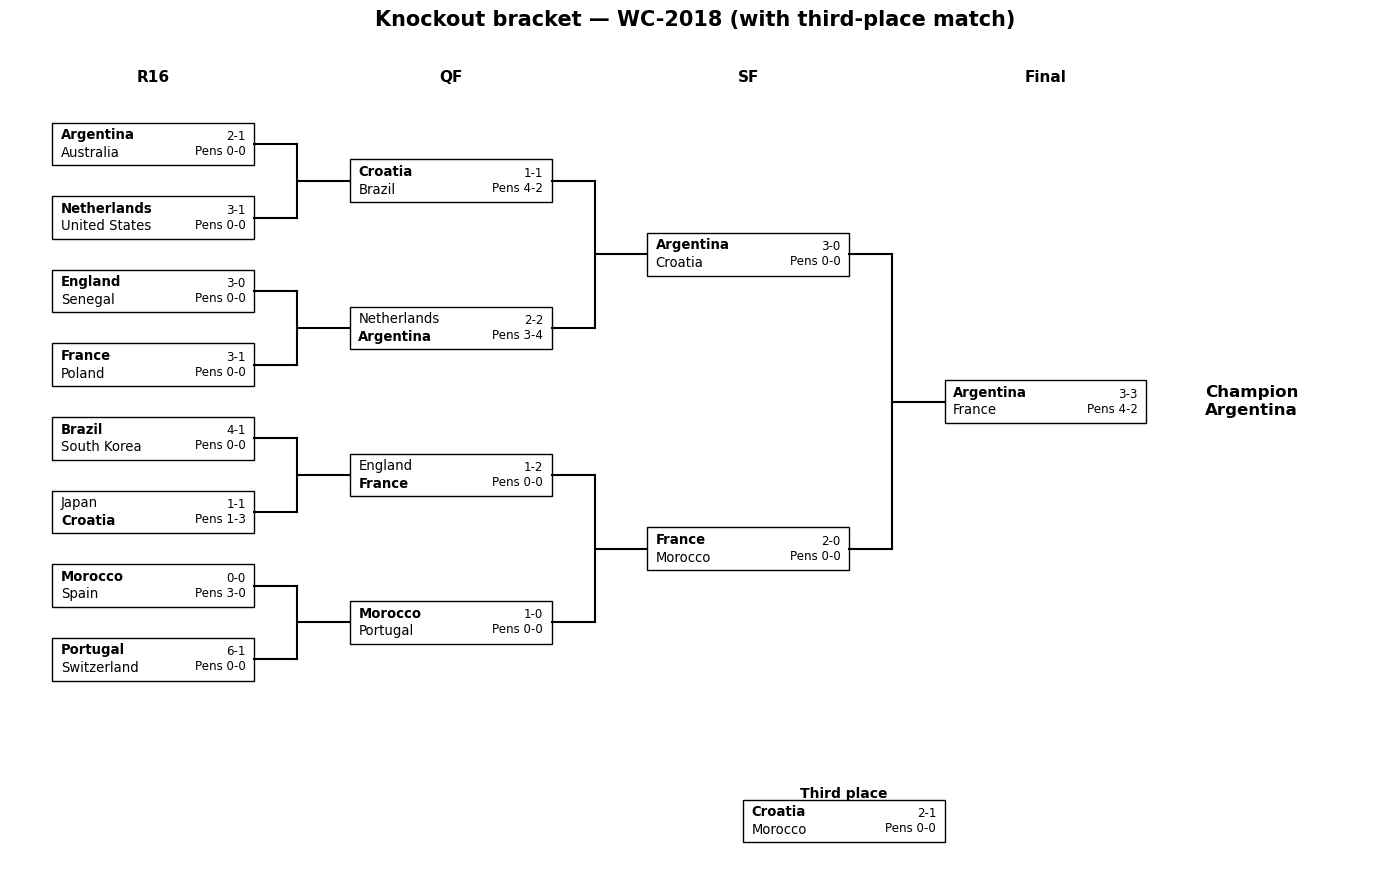

In [13]:
TOURNAMENT_ID = "WC-2018"

df = pd.read_sql(query, engine)
fig, ax, df_main, df_third = plot_knockout_bracket_with_third_place(
     df,
     tournament_id=TOURNAMENT_ID,
    figsize=(14, 9)
)
plt.show()
